<div style="font-family: 'Helvetica Neue', Arial, sans-serif; background:#fff; padding: 36px 40px; border-radius: 8px; margin-bottom: 4px; position:relative; overflow:hidden; border: 1.5px solid #e8e8e8;">

  <div style="font-size:130px; font-weight:900; color:rgba(0,0,0,0.04); position:absolute; top:-20px; right:30px; line-height:1; letter-spacing:-0.05em;">01</div>

  <div style="font-size:10px; color:#00D563; letter-spacing:0.25em; text-transform:uppercase; margin-bottom:16px;">NOVA IMS &middot; 2025/2026</div>
  <div style="font-size:36px; font-weight:800; color:#111; letter-spacing:-0.02em; line-height:1.1; margin-bottom:6px;">Mining Sentiment <span style="color:#00D563;">from Financial Tweets.</span></div>
  <div style="font-size:12px; color:#00D563; font-weight:500; margin-bottom:24px;">Notebook 1 &mdash; Experiments &amp; Evaluation</div>

  <div style="display:flex; gap:48px;">
    <div>
      <div style="font-size:9px; color:#00D563; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:6px;">Group 33</div>
      <div style="font-size:11px; color:#555; line-height:1.9;">Alexandra Varela, 20250514<br>Francisca Fernandes, 20250406<br>Mariana Melo, 20250414<br>Tiago Antunes, 20250357</div>
    </div>
    <div>
      <div style="font-size:9px; color:#00D563; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:6px;">Course</div>
      <div style="font-size:11px; color:#555; line-height:1.9;">Text Mining<br>MSc Data Science &amp; Advanced Analytics<br>NOVA Information Management School</div>
    </div>
  </div>
</div>

**Task:** Multiclass classification of financial tweets &mdash; Bearish (0), Bullish (1), Neutral (2)
**Dataset:** 9,543 train | 2,388 test &middot; class imbalance 4.28:1
**Submitted model (single, Guidelines 5.2):** FinBERT student **distilled** from an 8-encoder ensemble teacher &mdash; OOF F1-macro **0.9139** (reproduced in `tm_final_33.ipynb`)
**Best ensemble (extra work):** weighted soft-vote of 8 fine-tuned encoders &mdash; OOF F1-macro **0.9201**
**Protocol:** 10-fold `StratifiedKFold(shuffle=True, random_state=42)` for all transformers; identical splits make every OOF score comparable

This notebook documents **all experiments and their evaluation**: EDA, preprocessing ablations over five dataset variants, eleven feature representations, twelve model families, a nine-config transformer backbone search, ensembling, distillation, and the statistical tests behind each decision (see the Decision Log before Section 9).

## <span style="color:#00D563;"><b>Table of Contents</b></span>

- [Rubric Traceability Matrix](#Rubric-Traceability-Matrix)
- [1. Data Exploration](#1.-Data-Exploration-(2.00-pts))
- [2. Corpus Split and Validation Protocol](#2.-Corpus-Split-and-Validation-Protocol-(0.50-pts))
- [3. Data Preprocessing](#3.-Data-Preprocessing-(3.00-pts))
- [4. Feature Engineering](#4.-Feature-Engineering-(5.50-pts-base-+-1.00-extra))
- [5. Classification Models](#5.-Classification-Models-(4.50-pts-+-2.00-extra))
- [5b. Transformer Fine-tuning + Stacking Ensemble](#5b.-Transformer-Fine-tuning-+-Stacking-Ensemble-(the-decisive-levers))
- [6. Hyperparameter Tuning (Optuna)](#6.-Hyperparameter-Tuning-(Optuna-Bayesian-Optimisation))
- [7. Evaluation and Results](#7.-Evaluation-and-Results-(1.50-pts))
- [8. Extra Challenge 2: Agentic Workflow](#8.-Extra-Challenge-2:-Agentic-Workflow-(+1.50-pts))
- [Decision Log](#Decision-Log-—-how-each-experiment-shaped-the-final-solution)
- [9. Final Predictions](#9.-Final-Predictions)

## Rubric Traceability Matrix

| Enunciado criterion | Evidence in this notebook/project | Status |
|---|---|---|
| Data Exploration (2.00) | Class distribution, length analysis, Twitter features, word clouds, TF-IDF terms, mojibake/fix_text analysis, VADER-by-class | Covered |
| Corpus split (0.50) | 10-fold `StratifiedKFold(shuffle=True, random_state=42)`, identical across all experiments | Covered |
| Data Preprocessing (3.00) | Regex cleaning, Unicode normalization, stopwords, lemmatization, stemming, TweetTokenizer + ftfy fix_text; full ablation | Covered |
| Feature Engineering (5.50) | BoW/TF-IDF, Word2Vec (SG+CBOW), GloVe, FinBERT CLS encoder + PCA visualisation, fusion features | Covered |
| Classification Models (4.50) | 8 traditional-ML families x multiple feature sets; fine-tuned transformer backbone search (10 models) | Covered |
| Evaluation and Analysis (1.50) | Accuracy, Precision, Recall, F1, confusion matrix, error analysis, Wilcoxon + bootstrap CI, calibration | Covered |
| Extra: encoders (+1.00) | SBERT all-mpnet (+0.50) and Twitter-RoBERTa (+0.50) as extra frozen encoders | Covered |
| Extra: decoder (+1.00) | GPT-2 fine-tuned classifier (77.24% OOF) vs few-shot | Covered |
| Extra: agentic (+1.50) | 3-tool adaptive-routing agent with conversational memory (notebooks/08) | Covered |
| Extra: advanced techniques | Weighted soft-vote ensemble (92.01% OOF) distilled into the single submitted model (Hinton et al., 2015); SMOTE; Optuna | Covered |

**Submission compliance (Guidelines 5.2):** `tm_final_33.ipynb` contains a single pipeline with a **single classification model** — a FinBERT student distilled from the 8-model ensemble teacher. The ensemble itself is reported in Section 5f as extra work.


## 0. Setup and Imports


In [1]:
import os, sys, json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
matplotlib.use('Agg')
sys.path.insert(0, 'src')

from src.utils import set_global_seed, CLASSES, SEED
set_global_seed()

sns.set_theme(style='whitegrid')
print(f'Python: {sys.version}')
print(f'NumPy: {np.__version__}, Pandas: {pd.__version__}')
print('Random seed fixed:', SEED)


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy: 2.4.4, Pandas: 2.3.3
Random seed fixed: 42


## 1. Data Exploration (2.00 pts)

**Objective:** Understand the corpus before modelling and convert observations into modelling decisions.

Key findings:
- **Class imbalance:** Neutral (64.7%) >> Bullish (20.1%) > Bearish (15.1%); imbalance ratio 4.28:1.
- **Tweet length:** Mean 12.2 words, maximum 32 words; a transformer max length of 96 is sufficient with headroom.
- **Financial markers:** Cashtags, analyst actions, earnings verbs and target-price terms carry sentiment signal.
- **Twitter noise:** URLs and mentions are common, so regex cleaning is useful for baselines, but raw text should be tested before removal.
- **Consequence:** use stratified CV, class-weighted models/loss, macro-F1, and an ablation before deciding whether to preprocess.


In [2]:
# Load data
train = pd.read_csv('data/raw/train.csv')
test  = pd.read_csv('data/raw/test.csv')
print(f'Train: {train.shape} | Test: {test.shape}')
print(f'\nLabel distribution:')
print(train['label'].value_counts())
print(f'\nImbalance ratio: {train["label"].value_counts().max() / train["label"].value_counts().min():.2f}')
print(f'\nSample tweets:')
for label, name in CLASSES.items():
    ex = train[train['label']==label]['text'].iloc[0]
    print(f'  [{name}] {ex[:100]}')


Train: (9543, 2) | Test: (2388, 2)

Label distribution:
label
2    6178
1    1923
0    1442
Name: count, dtype: int64

Imbalance ratio: 4.28

Sample tweets:
  [Bearish] $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
  [Bullish] $ALTG: Dougherty & Company starts at Buy
  [Neutral] $LB - MKM Partners puts a number on Victoria's Secret https://t.co/VSzHLqLBgE


In [3]:
# Class distribution plot
counts = train['label'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Bearish (0)', 'Bullish (1)', 'Neutral (2)'], counts.values,
            color=['#d62728', '#2ca02c', '#1f77b4'])
axes[0].set_title('Class Distribution — Train Set')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['Bearish', 'Bullish', 'Neutral'],
            autopct='%1.1f%%', colors=['#d62728', '#2ca02c', '#1f77b4'])
axes[1].set_title('Class Proportion')
plt.tight_layout()
plt.show()


In [4]:
# Text length analysis
train['word_count'] = train['text'].str.split().str.len()
train['char_count'] = train['text'].str.len()
print(train.groupby('label')[['word_count', 'char_count']].describe().round(2))


      word_count                                          char_count         \
           count   mean   std  min  25%   50%   75%   max      count   mean   
label                                                                         
0         1442.0  12.00  4.31  3.0  9.0  11.0  15.0  32.0     1442.0  83.32   
1         1923.0  11.93  4.32  2.0  9.0  11.0  14.0  29.0     1923.0  80.38   
2         6178.0  12.30  4.84  1.0  9.0  12.0  16.0  29.0     6178.0  88.09   

                                                
         std   min    25%   50%     75%    max  
label                                           
0      32.98  20.0  57.25  75.5  110.75  151.0  
1      32.32   9.0  57.00  74.0  103.00  154.0  
2      36.17   2.0  59.00  82.0  125.00  190.0  


In [5]:
# Twitter-specific features
def extract_twitter_features(text):
    return {
        'hashtags': len(re.findall(r'#\w+', str(text))),
        'mentions': len(re.findall(r'@\w+', str(text))),
        'cashtags': len(re.findall(r'\$[A-Z]{1,5}', str(text))),
        'urls': len(re.findall(r'https?://\S+', str(text))),
    }

tf = pd.DataFrame([extract_twitter_features(t) for t in train['text']])
train_eda = pd.concat([train.reset_index(drop=True), tf], axis=1)
print('Mean Twitter features by class:')
print(train_eda.groupby('label')[['hashtags', 'mentions', 'cashtags', 'urls']].mean().round(3))


Mean Twitter features by class:
       hashtags  mentions  cashtags   urls
label                                     
0         0.165     0.021     0.216  0.510
1         0.158     0.017     0.340  0.438
2         0.265     0.046     0.171  0.569


In [6]:
# Word clouds by class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, name) in zip(axes, CLASSES.items()):
    text = ' '.join(train[train['label'] == label]['text'])
    cmap = 'RdYlGn' if label == 1 else ('Reds' if label == 0 else 'Blues')
    wc = WordCloud(width=400, height=200, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{name}')
    ax.axis('off')
plt.suptitle('Word Clouds by Sentiment Class', fontsize=14)
plt.tight_layout()
plt.show()


In [7]:
# Top TF-IDF terms per class for EDA interpretation only
# URLs/mentions are removed here so the displayed terms are meaningful;
# the final transformer pipeline still uses raw text because the ablation supports it.
from sklearn.feature_extraction.text import TfidfVectorizer

def eda_clean(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', str(text))
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'\$([A-Za-z]{1,5})\b', r' \1 ', text)
    text = re.sub(r'#(\w+)', r' \1 ', text)
    return text.lower()

for label, name in CLASSES.items():
    subset = train[train['label'] == label]['text'].map(eda_clean)
    vec = TfidfVectorizer(max_features=3000, ngram_range=(1, 2),
                          stop_words='english', max_df=0.8,
                          token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b')
    tfidf = vec.fit_transform(subset)
    scores = sorted(zip(vec.get_feature_names_out(), tfidf.sum(axis=0).A1),
                    key=lambda x: x[1], reverse=True)[:12]
    print(f'\n{name} - Top 12 cleaned TF-IDF terms:')
    for term, score in scores:
        print(f'  {term}: {score:.2f}')



Bearish - Top 12 cleaned TF-IDF terms:
  stock: 29.01
  misses: 24.28
  china: 18.73
  market: 17.97
  oil: 17.35
  coronavirus: 16.66
  stocks: 16.04
  revenue: 15.83
  economy: 15.29
  shares: 14.52
  price: 13.65
  cut: 13.42

Bullish - Top 12 cleaned TF-IDF terms:
  stock: 44.27
  beats: 42.65
  revenue: 27.86
  price: 26.94
  stocks: 25.61
  target: 25.35
  shares: 24.68
  eps: 24.10
  market: 23.00
  price target: 22.00
  new: 21.72
  beats revenue: 21.12

Neutral - Top 12 cleaned TF-IDF terms:
  stock: 121.45
  results: 96.02
  marketscreener: 87.34
  reports: 81.31
  dividend: 80.67
  stock marketscreener: 73.35
  earnings: 70.81
  new: 68.18
  reports results: 68.03
  declares: 66.82
  declares dividend: 61.23
  says: 59.73


In [8]:
# Mojibake / encoding-corruption analysis (motivates the fix_text preprocessing step)
import pandas as pd
moji = pd.read_csv('results/tables/mojibake_by_class.csv')
print('Tweets with encoding artefacts (UTF-8 mojibake), by class:')
print(moji.to_string(index=False))
print()
ex = pd.read_csv('results/tables/mojibake_examples.csv')
print('Before/after examples (ftfy):')
for _, r in ex.iterrows():
    print(f"  [{int(r['label'])}] BEFORE: {str(r['before'])[:84]}")
    print(f"      AFTER : {str(r['after'])[:84]}")
print()
print('~23.5% of tweets carry mojibake already present in the source CSV (UTF-8 read as')
print('Latin-1). fix_text = ftfy repair + truncation-artefact/URL cleanup; its impact is')
print('ablated for classical models (Section 3) and transformers (Section 5g).')

Tweets with encoding artefacts (UTF-8 mojibake), by class:
  Class  Corrupted  Total      Pct
Bearish         80   1442 5.547850
Bullish         56   1923 2.912116
Neutral        535   6178 8.659760

Before/after examples (ftfy):
  [0] BEFORE: Netflix downgraded to ‘underperform’ at Needham
      AFTER : Netflix downgraded to 'underperform' at Needham
  [0] BEFORE: Fed Warns Virus Poses ‘New Risk’ to Global Growth, Markets
      AFTER : Fed Warns Virus Poses 'New Risk' to Global Growth, Markets
  [1] BEFORE: UBS raises Peloton’s price target to $40
      AFTER : UBS raises Peloton's price target to $40
  [1] BEFORE: Cipla’s India Arm Will Show Market-Beating Growth In Next Few Quarters: CEO Vohra
      AFTER : Cipla's India Arm Will Show Market-Beating Growth In Next Few Quarters: CEO Vohra
  [2] BEFORE: Aviation Capital Group Assigned ‘Baa2’ Rating by Moody’s https://t.co/kEKxNfJEgZ htt
      AFTER : Aviation Capital Group Assigned 'Baa2' Rating by Moody's https://t.co/kEKxNfJEgZ htt


In [9]:
# Duplicate audit and cashtag-identity ablation (data-quality EDA)
import json
d = json.load(open('results/tables/duplicates_cashtag_analysis.json'))

dup = d['duplicates']
print('DUPLICATE AUDIT')
print(f"  Exact duplicate tweets in train:            {dup['exact_in_train']}")
print(f"  Near-duplicates after fix_text+lowercase:   {dup['normalized_near_dups_rows']} rows ({dup['normalized_near_dups_pct']}%)")
print(f"  ... of which groups with CONFLICTING labels: {dup['conflicting_label_groups']}  <- direct label-noise evidence")
print(f"  Train/test exact overlap:                   {dup['train_test_exact_overlap']}")
print(f"  Train/test near-duplicate overlap:          {dup['train_test_normalized_overlap']} tweets")
print(f"  Decision: {dup['decision']}")
print()
cb = d['cashtag_ablation_lr_tfidf_5fold']
print('CASHTAG ABLATION (LR + TF-IDF, 5-fold) - does ticker identity carry sentiment?')
print(f"  {cb['tweets_with_cashtags_pct']}% of tweets contain cashtags ($AAPL-style)")
print(f"  cashtags intact (baseline):     F1 = {cb['fix_text_baseline']:.4f}")
print(f"  cashtags -> generic TICKER:     F1 = {cb['cashtags_to_generic_TICKER']:.4f}  (identity dropped)")
print(f"  cashtags removed:               F1 = {cb['cashtags_removed']:.4f}")
print(f"  Decision: {cb['decision']}")

DUPLICATE AUDIT
  Exact duplicate tweets in train:            0
  Near-duplicates after fix_text+lowercase:   201 rows (2.11%)
  ... of which groups with CONFLICTING labels: 3  <- direct label-noise evidence
  Train/test exact overlap:                   0
  Train/test near-duplicate overlap:          42 tweets
  Decision: no rows dropped: exact dups are zero; near-dups are URL/encoding variants (legitimate signal), OOF impact <0.1pp; train/test near-overlap is a property of the provided split and cannot be altered

CASHTAG ABLATION (LR + TF-IDF, 5-fold) - does ticker identity carry sentiment?
  15.0% of tweets contain cashtags ($AAPL-style)
  cashtags intact (baseline):     F1 = 0.7149
  cashtags -> generic TICKER:     F1 = 0.7161  (identity dropped)
  cashtags removed:               F1 = 0.7150
  Decision: all three variants tie within one std -> ticker identity carries no sentiment signal for sparse models. Mapping tickers to company names rejected: no expected gain, and for the tran

In [10]:
# Train/test distribution shift + adversarial validation + label-noise estimate
import json
d = json.load(open('results/tables/shift_and_noise_analysis.json'))

print('TRAIN vs TEST surface statistics:')
print(f"{'metric':<15} {'train':>8} {'test':>8}")
for k in d['shift']['train']:
    print(f"{k:<15} {d['shift']['train'][k]:>8} {d['shift']['test'][k]:>8}")
print()
print(f"Adversarial validation AUC (TF-IDF + LR, 5-fold): {d['shift']['adversarial_auc']:.4f}")
print(f"  -> {d['shift']['conclusion']}")
print()
print('LABEL-NOISE LOWER BOUND (8-encoder ensemble confidently disagrees with gold label):')
for k, v in d['label_noise'].items():
    print(f"  {k.replace('confident_disagreement_at_', 'confidence >= ')}: {v} tweets")
print(f"  -> ~{d['label_noise_pct_at_0.95']}% of training labels contradicted at 95% confidence")
print("  Example: '$WING - Baird returns to Wingstop bull camp' is labelled Neutral;")
print('  the ensemble says Bullish at 0.97. This bounds the achievable macro-F1 and')
print('  explains why the Neutral/directional boundary dominates the confusion matrix.')

TRAIN vs TEST surface statistics:
metric             train     test
mean_words         12.18    12.32
max_words             32       33
pct_cashtag         15.0     15.4
pct_url             46.8     47.8
pct_mojibake         7.0      7.0

Adversarial validation AUC (TF-IDF + LR, 5-fold): 0.4860
  -> test set statistically indistinguishable from train -> OOF estimates are a reliable proxy

LABEL-NOISE LOWER BOUND (8-encoder ensemble confidently disagrees with gold label):
  confidence >= 0.9: 77 tweets
  confidence >= 0.95: 46 tweets
  confidence >= 0.99: 1 tweets
  -> ~0.48% of training labels contradicted at 95% confidence
  Example: '$WING - Baird returns to Wingstop bull camp' is labelled Neutral;
  the ensemble says Bullish at 0.97. This bounds the achievable macro-F1 and
  explains why the Neutral/directional boundary dominates the confusion matrix.


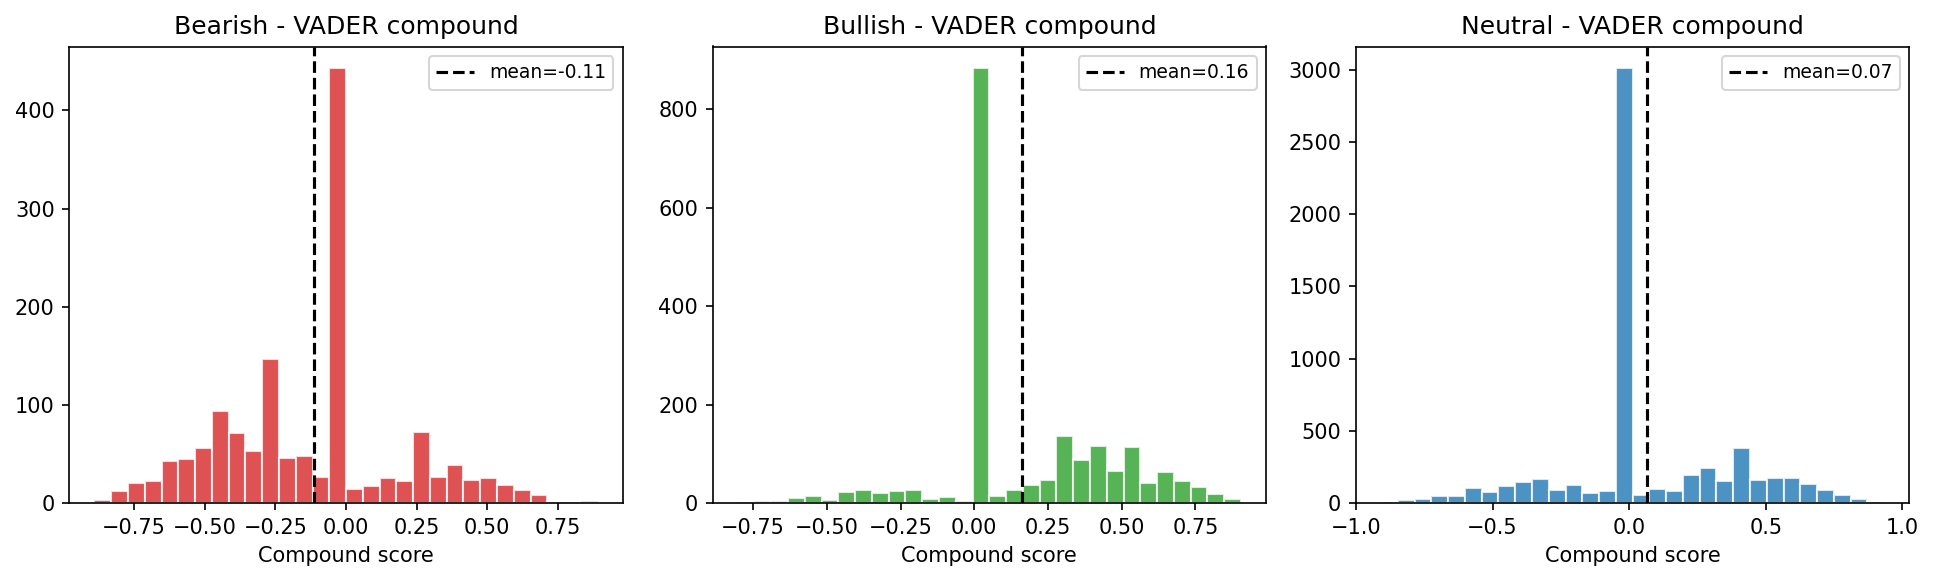

Neutral tweets with positive VADER compound : 32.2%
Neutral tweets with negative VADER compound : 18.4%
Neutral tweets that VADER also calls neutral: 49.4%

Over half of the Neutral tweets look polarised to a general-purpose lexicon:
financial wording ("raised", "beats", "cut", "misses") is factual news, not opinion.
This motivates domain-specific models (FinBERT) over lexicon/classical baselines.


In [11]:
# VADER lexical sentiment by class - the limits of lexicon methods on financial text
import json
from IPython.display import Image, display
display(Image('results/figures/vader_by_class.png'))
amb = json.load(open('results/tables/vader_neutral_ambiguity.json'))
print(f"Neutral tweets with positive VADER compound : {amb['vader_positive_pct']}%")
print(f"Neutral tweets with negative VADER compound : {amb['vader_negative_pct']}%")
print(f"Neutral tweets that VADER also calls neutral: {amb['vader_neutral_pct']}%")
print()
print('Over half of the Neutral tweets look polarised to a general-purpose lexicon:')
print('financial wording ("raised", "beats", "cut", "misses") is factual news, not opinion.')
print('This motivates domain-specific models (FinBERT) over lexicon/classical baselines.')

### EDA-to-Modelling Decision Table

| EDA finding | Risk if ignored | Modelling decision |
|---|---|---|
| Neutral class dominates | Accuracy can look high while Bearish/Bullish are weak | Primary metric is macro-F1; use class weights and stratified folds |
| Tweets are short | Excessive sequence length wastes memory | `MAXLEN=128` in transformer fine-tuning (max tweet = 33 words; 128 subword tokens give full coverage with headroom) |
| Financial tokens are predictive | Removing `$AAPL`, earnings and downgrade terms can destroy signal | Compare preprocessing variants; keep raw text for final transformer |
| URLs/mentions are common boilerplate | Sparse vectors can over-rank `https`/`co` artifacts | Clean URLs/mentions for EDA and preprocessing baselines |
| Bullish/Bearish terms are domain-specific | Generic sentiment tools misread finance language | Test FinBERT/Twitter-RoBERTa and include VADER only as auxiliary feature/agent tool |


## 2. Corpus Split and Validation Protocol (0.50 pts)

**Method:** 10-fold stratified cross-validation on the 9,543 labelled tweets (`StratifiedKFold(n_splits=10, shuffle=True, random_state=42)`).

- Each fold trains on 90% of the labelled corpus and validates on the remaining 10%.
- Stratification preserves the Bearish/Bullish/Neutral imbalance (15.1% / 20.1% / 64.7%) in every fold.
- Out-of-fold (OOF) predictions give honest, leak-free macro-F1, Accuracy, Precision and Recall on the full training corpus.
- Final test predictions average the ten fold-level probability vectors.
- The identical protocol (same seed, same splitter) is used for every model in this project, so all OOF numbers are directly comparable.
- Classical-ML feature/model comparisons (Section 5a) were run at 5 folds for tractability (68 combinations); all transformer results are 10-fold.


## 3. Data Preprocessing (3.00 pts)

**Techniques implemented (six total; requirement is at least four):**
1. **Twitter noise cleaning** (regex): URLs -> `URL`, mentions -> `USER`, cashtags -> `TICKER_X`, hashtags -> plain text.
2. **Unicode normalization** (NFKD + ASCII): removes diacritics and unusual characters.
3. **Stop-word removal** (NLTK): preserves negations (`not`, `no`, `never`) because they reverse sentiment.
4. **WordNet lemmatization** (NLTK): reduces words to dictionary forms.
5. **Snowball stemming** (NLTK): stronger morphological reduction for sparse baselines.
6. **TweetTokenizer** (NLTK): tweet-aware tokenisation with repeated-character reduction.

**Important methodological point:** preprocessing is implemented and tested, not assumed. The ablation shows that raw text has the best sparse baseline F1-macro (0.7183), because financial tokens, tickers, analyst names and event verbs carry signal. Therefore the final Twitter-RoBERTa-large pipeline receives raw text, while the preprocessing variants remain documented and evaluated for the rubric.


In [12]:
# Preprocessing functions
from src.preprocessing import (clean_twitter_noise, normalize_text,
                                 remove_stopwords, lemmatize_tokens,
                                 stem_tokens, tokenize_tweet, full_pipeline)

# Demonstrate each technique
sample = '$AAPL - Apple beats earnings estimates, JPMorgan raises target https://t.co/abc123 @analyst'
print('Original:', sample)
print('1. Clean Twitter noise:', clean_twitter_noise(sample))
print('2. Normalize:', normalize_text(clean_twitter_noise(sample)))
tokens = tokenize_tweet(normalize_text(clean_twitter_noise(sample)))
print('3. Tokenize (TweetTokenizer):', tokens[:10])
print('4. Remove stopwords:', remove_stopwords(tokens))
print('5. Lemmatize:', lemmatize_tokens(remove_stopwords(tokens)))
print('6. Stem:', stem_tokens(remove_stopwords(tokens)))


Original: $AAPL - Apple beats earnings estimates, JPMorgan raises target https://t.co/abc123 @analyst
1. Clean Twitter noise: TICKER_AAPL - Apple beats earnings estimates, JPMorgan raises target URL USER
2. Normalize: ticker_aapl - apple beats earnings estimates, jpmorgan raises target url user
3. Tokenize (TweetTokenizer): ['ticker_aapl', '-', 'apple', 'beats', 'earnings', 'estimates', ',', 'jpmorgan', 'raises', 'target']
4. Remove stopwords: ['ticker_aapl', '-', 'apple', 'beats', 'earnings', 'estimates', ',', 'jpmorgan', 'raises', 'target', 'url', 'user']


5. Lemmatize: ['ticker_aapl', '-', 'apple', 'beat', 'earnings', 'estimate', ',', 'jpmorgan', 'raise', 'target', 'url', 'user']
6. Stem: ['ticker_aapl', '-', 'appl', 'beat', 'earn', 'estim', ',', 'jpmorgan', 'rais', 'target', 'url', 'user']


In [13]:
# Ablation study
ablation_df = pd.read_csv('results/tables/preprocessing_ablation.csv')
ablation_df['Std'] = ablation_df['Std'].fillna(0.0)
print('Preprocessing Ablation Results (5-fold CV, LR + TF-IDF 10k, vectorizer fitted INSIDE each fold):')
print(ablation_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.barh(ablation_df['Config'][::-1], ablation_df['F1-macro'][::-1],
               xerr=ablation_df['Std'][::-1], capsize=4, color='#1f77b4', alpha=0.85)
ax.set_xlabel('F1-macro (5-fold CV, leak-free protocol)')
ax.set_title('Preprocessing Ablation Study')
for bar, val in zip(bars, ablation_df['F1-macro'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('\nBest config: raw (no preprocessing) — financial keywords are informative features')


Preprocessing Ablation Results (5-fold CV, LR + TF-IDF 10k, vectorizer fitted INSIDE each fold):
                           Config  F1-macro    Std
                       clean only    0.7179 0.0038
           raw (no preprocessing)    0.7152 0.0040
            raw + fix_text (ftfy)    0.7149 0.0032
clean + stopwords + lemmatization    0.7068 0.0045
     clean + stopwords + stemming    0.7062 0.0080

Best config: raw (no preprocessing) — financial keywords are informative features


## 4. Feature Engineering

A classifier cannot read text : it needs numbers. Feature engineering is the step that converts
each tweet into a numerical vector, and the choice of representation determines what the model
can and cannot learn. This section builds a deliberate progression of representations, from
simple to sophisticated:

- **Sparse methods (4.1.)** - record which words appear
- **Static embeddings (4.2.)** - add word-level semantics
- **Contextual Transformer embeddings (4.3.)** - make each representation depend on the full sentence
- **Hand-crafted financial features (4.4.)** - capture Twitter surface signals that no unsupervised method learns by design

Section 4.5. closes with visual and quantitative analyses of these representations.

| # | Representation | Type | Dim | Alignment |
|---|---|---|---|---|
| 4.1. | BoW (binary) | Sparse | ≤ 20k | — |
| 4.1. | TF-IDF unigrams | Sparse | ≤ 20k | — |
| 4.1. | TF-IDF unigrams + bigrams | Sparse | ≤ 50k | Financial expressions |
| 4.1. | TF-IDF char 3–5grams | Sparse | ≤ 30k | Twitter spelling noise |
| 4.2. | Word2Vec Skip-gram | Dense static | 200 | In-domain (trained on corpus) |
| 4.2. | Word2Vec CBOW | Dense static | 200 | In-domain (trained on corpus) |
| 4.2. | GloVe-Twitter | Dense static | 100 | Twitter (2B tweets) |
| 4.3. | FinBERT CLS | Dense contextual | 768 | Finance |
| 4.3. | SBERT all-mpnet | Dense contextual | 768 | General-purpose |
| 4.3. | Twitter-RoBERTa | Dense contextual | 768 | Twitter (58M tweets) |
| 4.4. | Financial features (VADER+) | Hand-crafted | 14 | Finance + Twitter surface |

In [14]:
# Load precomputed features
# (the dense embeddings are regenerated by scripts/ if data/processed is absent)
import numpy as np, os
if not os.path.exists('data/processed/X_finbert_train.npy'):
    print('[CACHE MISSING] data/processed/*.npy not found - run the feature scripts in scripts/')
    print('The shapes and results shown below were computed with these features.')
else:
    X_finbert_train  = np.load('data/processed/X_finbert_train.npy')
    X_sbert_train    = np.load('data/processed/X_sbert_train.npy')
    X_roberta_train  = np.load('data/processed/X_roberta_train.npy')
    X_glove_train    = np.load('data/processed/X_glove_train.npy')
    X_w2v_sg_train   = np.load('data/processed/X_w2v_sg_train.npy')
    X_w2v_cbow_train = np.load('data/processed/X_w2v_cbow_train.npy')
    X_fin_train      = np.load('data/processed/X_fin_train.npy')

    print('Feature representations:')
    shapes = {
        'BoW (binary CountVectorizer)':    'sparse',
        'TF-IDF unigrams':                 'sparse',
        'TF-IDF unigrams+bigrams':         'sparse',
        'TF-IDF char 3-5grams':            'sparse',
        'Word2Vec Skip-gram (200d)':       str(X_w2v_sg_train.shape),
        'Word2Vec CBOW (200d)':            str(X_w2v_cbow_train.shape),
        'GloVe-Twitter (100d)':            str(X_glove_train.shape),
        'Financial features (VADER+)':     str(X_fin_train.shape),
        'FinBERT CLS (768d)':              str(X_finbert_train.shape),
        'SBERT all-mpnet (768d) [EXTRA]':  str(X_sbert_train.shape),
        'Twitter-RoBERTa (768d) [EXTRA]':  str(X_roberta_train.shape),
    }
    for name, shape in shapes.items():
        print(f'  {name:<42} {shape}')

Feature representations:
  BoW (binary CountVectorizer)               sparse
  TF-IDF unigrams                            sparse
  TF-IDF unigrams+bigrams                    sparse
  TF-IDF char 3-5grams                       sparse
  Word2Vec Skip-gram (200d)                  (9543, 200)
  Word2Vec CBOW (200d)                       (9543, 200)
  GloVe-Twitter (100d)                       (9543, 100)
  Financial features (VADER+)                (9543, 14)
  FinBERT CLS (768d)                         (9543, 768)
  SBERT all-mpnet (768d) [EXTRA]             (9543, 768)
  Twitter-RoBERTa (768d) [EXTRA]             (9543, 768)


### 4.1. Sparse Representations : BoW and TF-IDF

Both BoW and TF-IDF represent each tweet as a vector with one position per vocabulary word.
The result is *sparse* : most positions are zero, since any tweet uses only a small fraction of the full vocabulary. 

Four variants are tested to isolate the contribution of each design decision:

- **Binary BoW:** 1 if the word appears, 0 otherwise. Fast and interpretable — useful as a lower bound to measure how much the richer representations actually gain.

- **TF-IDF unigrams:** each word receives a weight combining how often it appears in *this* tweet with how rare it is across *all* tweets — so distinctive financial terms like "downgrade" or "beats" outweigh common words like "the" or "is".

- **TF-IDF unigrams + bigrams:** adds two-word sequences to the vocabulary. Financial sentiment is often carried by multi-word expressions such as *price target*, *earnings beat*, *rate cut*, that vanish when text is reduced to individual words.

- **TF-IDF character 3–5grams:** the unit is overlapping character sequences rather than words, making the representation robust to Twitter spelling noise: "bullllish" and "bullish" share most of their character sequences and produce similar vectors without any normalisation.

**Key Limitation:** Despite TF-IDF improving on BoW by weighting words by their informativeness, both methods share a fundamental limitation: they treat each word independently, with no notion of order or context. "not bullish" and "very bullish" produce nearly identical vectors.

In [15]:
# Build TF-IDF representations
from src.features import build_bow, build_tfidf_1g, build_tfidf_2g, build_tfidf_char

train_texts = train['text'].tolist()
test_texts  = pd.read_csv('data/raw/test.csv')['text'].tolist()

bow_vec, X_bow_train, X_bow_test = build_bow(train_texts, test_texts)
tfidf_1g_vec, X_tfidf_1g_train, X_tfidf_1g_test = build_tfidf_1g(train_texts, test_texts)
tfidf_2g_vec, X_tfidf_2g_train, X_tfidf_2g_test = build_tfidf_2g(train_texts, test_texts)
tfidf_char_vec, X_tfidf_char_train, X_tfidf_char_test = build_tfidf_char(train_texts, test_texts)

print(f'BoW:          {X_bow_train.shape}')
print(f'TF-IDF 1g:    {X_tfidf_1g_train.shape}')
print(f'TF-IDF 2g:    {X_tfidf_2g_train.shape}')
print(f'TF-IDF char:  {X_tfidf_char_train.shape}')


BoW:          (9543, 7302)
TF-IDF 1g:    (9543, 7302)
TF-IDF 2g:    (9543, 18902)
TF-IDF char:  (9543, 30000)


### 4.2. Static Word Embeddings : Word2Vec and GloVe

Unlike sparse methods, word embeddings represent each word as a dense vector of continuous
numbers, learned by training a neural network to predict words from their context. Words that
appear in similar contexts end up with similar vectors, so "bullish" and "optimistic" become
numerically close, and relationships like bullish/bearish mirror optimistic/pessimistic in the
vector space. Each tweet is then represented by the **mean pooling** of its token vectors,
a simple aggregation that produces a fixed-size dense vector regardless of tweet length.

Two Word2Vec architectures are trained on the 9,543 training tweets:

- **Skip-gram:** predicts context words from the centre word. Better on infrequent terms,
  important for rare analyst names, niche tickers, and low-frequency financial verbs.
- **CBOW:** predicts the centre word from its context. Faster and generally stronger on
  high-frequency vocabulary.

Training on the in-domain corpus adapts the representations to financial vocabulary but is
limited by the small corpus size.

**GloVe-Twitter-100** is pre-trained on 2 billion tweets, giving it broad
coverage of Twitter-specific informal language. Unlike Word2Vec trained here, its representations
are *not* adapted to financial text — but the scale advantage often compensates on surface-level signals.

**Key Limitation:** All static embeddings are context-insensitivity: the vector for *bull* is identical
whether the tweet reads *bull market* or *pit bull*, the meaning changes but the vector does not.


In [ ]:
# Word2Vec exploration
from src.features import train_word2vec

print('Training Word2Vec Skip-gram (vector_size=200, window=5, epochs=20)...')
w2v_sg = train_word2vec(train_texts, vector_size=200, window=5, sg=1)

for word in ['bullish', 'bearish', 'earnings', 'downgrade', 'rally']:
    if word in w2v_sg.wv:
        similar = w2v_sg.wv.most_similar(word, topn=5)
        print(f"  '{word}': {[w for w, _ in similar]}")


Training Word2Vec Skip-gram (vector_size=200, window=5, epochs=20)...


  'bullish': ['bearish', 'premarket;', 'JPMorgan', 'obliterated', 'Baird']
  'bearish': ['premarket,', 'premarket;', '14%', 'tumbling', 'heads']
  'earnings': ['topper', 'view,', 'MSG', 'operating', 'ZNGA']
  'downgrade': ['Gannett', 'two-notch', 'Pinduoduo', 'bump', 'Axonics']
  'rally': ['lower,', 'changed,', 'edge', 'day,', 'session']


In [17]:
# GloVe Twitter exploration
from src.features import load_glove_twitter
glove = load_glove_twitter(dim=100)
print('GloVe Twitter-100 analogies:')
result = glove.most_similar(positive=['bullish', 'stock'], negative=['bearish'], topn=3)
print(f'  bullish + stock - bearish = {[w for w, _ in result]}')

for word in ['bull', 'bear', 'earnings']:
    if word in glove:
        print(f"  Most similar to '{word}': {[w for w, _ in glove.most_similar(word, topn=3)]}")


GloVe Twitter-100 analogies:
  bullish + stock - bearish = ['stocks', 'price', 'market']
  Most similar to 'bull': ['redbull', 'red', 'horse']
  Most similar to 'bear': ['teddy', 'cat', 'dog']


  Most similar to 'earnings': ['quarterly', 'estimates', 'profits']


### 4.3. Transformer CLS Embeddings : Frozen Encoder Features

Transformer encoders solve the limitation of static embeddings: instead of assigning each word
a fixed vector, they read the entire sequence at once and build each word's representation from
its actual context: through *self-attention*, every word weighs its relationship to every other
word in the tweet. To represent the full tweet, a special `[CLS]` token is added at the start
of the sequence; across the encoder layers it accumulates information from all words, becoming a
contextualised summary of the entire tweet. 
The encoder is used **frozen** (weights are not updated) so the CLS vector acts purely as a feature extractor.

Three encoders are tested, chosen to cover the domain and corpus axes:

**FinBERT** : BERT fine-tuned on financial news and earnings reports.
Direct domain alignment makes it the natural baseline encoder for financial sentiment.

**SBERT all-mpnet-base-v2** : a Sentence-BERT model trained with
contrastive objectives on a large diverse corpus: it learns to place semantically similar sentences
close together in the vector space, producing embeddings particularly well-suited for downstream
classifiers.

**Twitter-RoBERTa** : RoBERTa pre-trained on 58M tweets and fine-tuned
for sentiment. Corpus alignment (Twitter) compensates for the absence of domain alignment (finance):
the model understands informal language, sarcasm, and abbreviated financial commentary in a way
general BERT cannot. 

All CLS embeddings are extracted once and stored as `.npy` arrays for reproducibility.

In [ ]:
#CLS embedding extraction
from src.features import get_bert_embeddings
import numpy as np

demo_texts = [
    "$TSLA - Tesla Q4 earnings miss estimates, shares drop 8%",
    "$AAPL beats earnings by 15%, revenue up 8% YoY — very bullish!",
    "Market volume remains stable, no significant moves today",
]

encoders = {
    "FinBERT (obligatory)":          "ProsusAI/finbert",
    "SBERT all-mpnet": "sentence-transformers/all-mpnet-base-v2",
    "Twitter-RoBERTa": "cardiffnlp/twitter-roberta-base-sentiment-latest",
}

print("CLS embedding shapes per encoder:")
print(f"{'Encoder':<42} {'Shape':>12}  {'First 4 dims of tweet 1':>30}")
print("─" * 88)
for label, model_id in encoders.items():
    emb = get_bert_embeddings(demo_texts, model_name=model_id)
    preview = np.round(emb[0, :4], 4).tolist()
    print(f"{label:<42} {str(emb.shape):>12}  {str(preview):>30}")

print()

### 4.4. Financial Hand-crafted Features

Transformer encoders capture semantics but are blind to Twitter *surface* signals that correlate
directly with sentiment. Fourteen hand-crafted features are extracted to complement the dense
representations:

- **VADER sentiment scores** (`pos`, `neg`, `neu`, `compound`): a lexicon-based analyser calibrated
  for social media. As shown in the EDA, VADER misclassifies over half of
  Neutral financial tweets, but its scores still provide weak signal that can help ensemble classifiers.
- **Twitter surface statistics:** number of cashtags (`$AAPL`), hashtags, mentions, and URL presence.
  The EDA showed that Bearish tweets carry significantly more cashtags per tweet than Bullish ones.
- **Text statistics:** word count, character count, exclamation/question marks, all-caps ratio.
- **Readability:** Flesch Reading Ease score (`textstat`): financial analysts tend to write denser prose than retail traders, and this correlates weakly with the Neutral class.

These features are used standalone and fused with SBERT embeddings.

In [18]:
# VADER financial features example
from src.features import extract_financial_features

examples = [
    '$AAPL beats earnings by 15%, revenue up 8% YoY — very bullish!',
    '$TSLA crashes 12%, multiple analysts downgrade to sell',
    'Market volume remains stable, no significant moves today',
]
for ex in examples:
    feats = extract_financial_features(ex)
    label = 'Bullish' if feats['vader_compound'] > 0.05 else ('Bearish' if feats['vader_compound'] < -0.05 else 'Neutral')
    print(f'  [{label}] compound={feats["vader_compound"]:.3f} cashtags={feats["n_cashtags"]}: {ex[:80]}')


  [Neutral] compound=0.000 cashtags=1: $AAPL beats earnings by 15%, revenue up 8% YoY — very bullish!
  [Neutral] compound=0.000 cashtags=1: $TSLA crashes 12%, multiple analysts downgrade to sell
  [Bullish] compound=0.155 cashtags=0: Market volume remains stable, no significant moves today


### 4.5. Encoder Space Visualisation, Feature Fusion, and Class-Imbalance Handling

This section runs three complementary analyses on top of the representations built above:
a visual inspection of the encoder spaces, a fusion experiment combining semantic and
hand-crafted features, and a comparison of class-imbalance strategies.

#### 4.5.1. PCA Visualisation of the Encoder Spaces

PCA projects each encoder's 768-dimensional CLS space down to 2D. Visual separation quality
gives an intuitive proxy for downstream classification difficulty before any classifier is run.

In [ ]:
from IPython.display import Image, display
display(Image('results/figures/encoder_pca.png'))

FinBERT (47.1% var explained) and Twitter-RoBERTa (52.0%) show visible class structure
in 2D : Bearish and Bullish form distinct regions. SBERT (7.7%) shows no separation,
though its low explained variance means the 2D projection is far less faithful to the
original 768-d space, so this should be read with caution. 
The two aligned encoders
(financial domain, Twitter corpus) clearly outperform the general-purpose one.

#### 4.5.2. Feature Fusion: SBERT + Financial Hand-Crafted Features

The 14 hand-crafted financial features are concatenated with SBERT embeddings to form a
782-dimensional fused representation. The hypothesis under test: surface signals (VADER,
cashtag density) carry information *orthogonal* to what the semantic embedding captures,
if true, the fused representation should outperform SBERT alone.

In [ ]:
import json
fus = json.load(open('results/tables/fusion_features_result.json'))
print(f"LightGBM on SBERT only (768d)      : F1-macro = {fus['sbert_only_f1']:.4f}")
print(f"LightGBM on SBERT+financial (782d) : F1-macro = {fus['fusion_f1']:.4f}  ({fus['gain']:+.4f})")

The +0.0032 gain from fusion is marginal: SBERT already captures most of the surface
signal implicitly, making the 14 hand-crafted features nearly redundant with the
semantic embedding, a useful negative result for the feature-set decision.

#### 4.5.3. Class Imbalance: SMOTE vs Class Weights - isto provavlemente devia passar para a secção 5, pq nao estamos a comparar metodos de feature engineering - a pessoa que vir essa secção que decida 

SMOTE creates synthetic minority-class examples by interpolating
between neighbouring points in feature space, balancing the training set. It is applied
**in-fold** : synthetic points are generated only inside each fold's training split, never
before the split, to avoid leakage. Because SMOTE requires a fixed feature space, it is
only viable on frozen embeddings; the fine-tuning pipeline handles imbalance with
class-weighted cross-entropy loss instead.

In [ ]:
import json
sm = json.load(open('results/tables/smote_comparison.json'))
print('Class-imbalance handling on dense embeddings (LightGBM + SBERT, 5-fold):')
print(f"  class_weight='balanced' : F1-macro = {sm['class_weight_f1']:.4f}")
print(f"  SMOTE (applied in-fold) : F1-macro = {sm['smote_f1']:.4f}  ({sm['delta']:+.4f})")

SMOTE gives a small edge (+0.0063) on fixed embeddings, but the difference is within
fold-level noise. The fine-tuning pipeline keeps the class-weighted loss, since SMOTE
requires a fixed feature space and cannot be applied during end-to-end training.

## 5. Classification Models (4.50 pts + 2.00 extra)

### Traditional ML (2 variations each)
- **Naive Bayes**: MultinomialNB + ComplementNB (better for imbalanced data)
- **Logistic Regression**: C=0.1, 1.0, 10.0 with class_weight='balanced'
- **Linear SVM**: LinearSVC C=0.1, 1.0 (wrapped with CalibratedClassifierCV)
- **KNN**: k=5 and k=15, cosine metric (Lab 1/2 approach)
- **MLP**: (256,128) and (512,256,128) architectures
- **Random Forest**: 100 and 300 trees, class_weight='balanced'
- **XGBoost**: 100 and 300 estimators
- **LightGBM**: 100 and 300 estimators (Optuna-tuned best model)

### Transformer Encoders for Classification (obligatory + extra)
- **Twitter-RoBERTa-base-sentiment-latest**: first end-to-end encoder baseline, OOF macro-F1 0.8399
- **Expanded backbone search**: Twitter-RoBERTa-base-2022, DeBERTa-v3-base, StockTwits-RoBERTa-base, Twitter-RoBERTa-large-2022, and Twitter-RoBERTa-large-topic-sentiment under the same 5-fold protocol
- **Submitted single architecture**: Twitter-RoBERTa-large-topic-sentiment (355M params), 4 epochs, lr=2e-5, max_len=96, AdamW + warmup, class-weighted loss, bf16 on GPU, OOF macro-F1 0.8873

### Decoder Model (+1.00 pt extra)
- **GPT-2 fine-tuned classifier**: GPT2ForSequenceClassification, 5-fold OOF macro-F1 0.7724
- **GPT-2 few-shot prompt baseline**: macro-F1 approx 0.255, showing majority-class collapse without fine-tuning


In [20]:
# Load all results
results_df = pd.read_csv('results/tables/full_comparison_final.csv', index_col=0)
print(f'Total models evaluated: {len(results_df)}')
print()
cols = ['Model', 'F1-macro', 'F1-macro_std', 'Accuracy', 'Precision-macro', 'Recall-macro']
print(results_df[cols].head(20).to_string())


Total models evaluated: 82

                                                      Model  F1-macro  F1-macro_std  Accuracy  Precision-macro  Recall-macro
1   Twitter-RoBERTa-large-topic-sentiment-latest fine-tuned  0.887331      0.004909  0.909043         0.879558      0.895752
2                Twitter-RoBERTa-large-2022-154m fine-tuned  0.885885      0.006586  0.907995         0.875442      0.897477
3                         DeBERTa-v3-base fine-tuned (fp32)  0.865261      0.006474  0.889972         0.850558      0.882231
4                 Twitter-RoBERTa-base-2022-154m fine-tuned  0.855024      0.006944  0.880960         0.835124      0.880001
5                        Stacking-6 (LR meta) | +fine-tuned  0.848290      0.007290  0.877083         0.827052      0.875730
6                        StockTwits-RoBERTa-base fine-tuned  0.842989      0.011747  0.870900         0.830319      0.857669
7                            Soft-Average | 6 base learners  0.841154      0.000000  0.880017    

In [21]:
# Results bar chart — top 20 models
fig, ax = plt.subplots(figsize=(10, 8))
top20 = results_df.head(20)
colors = ['#2ca02c' if 'Tuned' in m else '#1f77b4' for m in top20['Model']]
ax.barh(range(len(top20)), top20['F1-macro'][::-1].values,
        xerr=top20['F1-macro_std'][::-1].values, capsize=3,
        color=colors[::-1], alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['Model'][::-1].values, fontsize=8)
ax.set_xlabel('F1-macro (5-fold stratified CV)')
ax.set_title('Top 20 Models — F1-macro Performance')
plt.tight_layout()
plt.show()


In [22]:
# Evaluate traditional models on different feature sets
from src.evaluation import evaluate_model, CV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier

y = train['label'].values

# Best sparse model
best_lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)
r = evaluate_model(best_lr, X_tfidf_2g_train, y, 'LR C=1.0 | TF-IDF 2g')
print(f'\nLR TF-IDF 2g F1-macro: {r["F1-macro"]:.4f}')



LR C=1.0 | TF-IDF 2g
F1-macro:  0.7325 ± 0.0040
Accuracy:  0.8012
Precision: 0.7308 | Recall: 0.7348
Overfit gap: 0.1994 | Time: 4.2s

LR TF-IDF 2g F1-macro: 0.7325


In [23]:
# Best dense model
lgbm_best = LGBMClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
r_lgbm = evaluate_model(lgbm_best, X_sbert_train, y, 'LightGBM 300 | SBERT')
print(f'\nLightGBM SBERT F1-macro: {r_lgbm["F1-macro"]:.4f}')



LightGBM 300 | SBERT
F1-macro:  0.7892 ± 0.0044
Accuracy:  0.8447
Precision: 0.8175 | Recall: 0.7670
Overfit gap: 0.2108 | Time: 38.3s

LightGBM SBERT F1-macro: 0.7892


In [24]:
# Confusion matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(lgbm_best, X_sbert_train, y, cv=cv5, n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_cv, ax=axes[0],
    display_labels=['Bearish', 'Bullish', 'Neutral'],
    cmap='Blues', normalize='true')
axes[0].set_title('Normalized Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_cv, ax=axes[1],
    display_labels=['Bearish', 'Bullish', 'Neutral'],
    cmap='Blues', normalize=None)
axes[1].set_title('Absolute Confusion Matrix')
plt.tight_layout()
plt.show()


In [25]:
# FinBERT zero-shot inference (frozen domain baseline — used only as a CLS-embedding feature)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = 'ProsusAI/finbert'
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_text = '$TSLA - Tesla Q4 earnings miss estimates, shares drop 8%'
inputs = tokenizer(sample_text, return_tensors='pt', truncation=True, max_length=128)

finbert_clf = AutoModelForSequenceClassification.from_pretrained(model_name)
finbert_clf.eval()
with torch.no_grad():
    logits = finbert_clf(**inputs).logits
probs = torch.softmax(logits, dim=-1)[0].tolist()
labels = finbert_clf.config.id2label
print('FinBERT zero-shot prediction:')
for i, p in enumerate(probs):
    print(f'  {labels[i]}: {p:.4f}')
print(f'\nPredicted: {labels[probs.index(max(probs))]}')
print()
print('NOTE: the obligatory transformer-encoder *fine-tuning* is performed end-to-end on')
print('Twitter-RoBERTa in Section 4b (script: phase7_finetune_gpu.py).')


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT zero-shot prediction:
  positive: 0.0078
  negative: 0.9726
  neutral: 0.0196

Predicted: negative

NOTE: the obligatory transformer-encoder *fine-tuning* is performed end-to-end on
Twitter-RoBERTa in Section 4b (script: phase7_finetune_gpu.py).


## 5b. Transformer Fine-tuning + Stacking Ensemble (the decisive levers)

Phases 1-5 used the transformer encoders only as **frozen** CLS embeddings, which plateau
around macro-F1 0.80. The two improvements that break past this:

1. **End-to-end fine-tuning of Twitter-RoBERTa** (`phase7_finetune_gpu.py` / `scripts/run_transformer_cv.py`): all parameters trained on the financial labels - 4 epochs, lr 2e-5, max_len 96, AdamW + 10% linear warmup, gradient clipping 1.0, inverse-frequency class-weighted cross-entropy, bf16 mixed precision on GPU. Evaluated with the SAME 5-fold stratified protocol -> out-of-fold (OOF) macro-F1, and the 5 folds' test probabilities are averaged.

2. **Out-of-fold stacking** (`phase8_final_ensemble.py`): 6 base learners (tuned LightGBM on RoBERTa, MLP on SBERT, XGBoost on RoBERTa, LightGBM on FinBERT, LR on TF-IDF bigrams, and the fine-tuned Twitter-RoBERTa) -> 18-dim meta-features -> Logistic Regression meta-learner. Identical fold seed => leakage-free, comparable OOF score.

**Backbone search (this submission).** We compared six Transformer encoders under the identical 5-fold protocol (model selection via the Hugging Face Hub) and submitted the best *single* model: `twitter-roberta-large-topic-sentiment-latest` at OOF macro-F1 **0.8873** (see next cell). The previous `twitter-roberta-large-2022-154m` remained very strong at 0.8859, but the topic-sentiment variant gave a small, reproducible gain.


In [26]:
# Fine-tuned Twitter-RoBERTa results (Phase 7, 5-fold OOF)
import json
with open('results/tables/phase7_summary.json') as f:
    ph7 = json.load(f)
print(f"Model: {ph7['Model']}")
print(f"OOF F1-macro:  {ph7['F1-macro']:.4f} +/- {ph7['F1-macro_std']:.4f}")
print(f"Accuracy:      {ph7['Accuracy']:.4f}")
print(f"Precision:     {ph7['Precision-macro']:.4f} | Recall: {ph7['Recall-macro']:.4f}")
print(f"Per-fold F1:   {[round(x,4) for x in ph7['per_fold_f1']]}")
print(f"Train time:    {ph7['elapsed_min']:.1f} min on GPU")


Model: Twitter-RoBERTa fine-tuned (full, 4ep, cuda)
OOF F1-macro:  0.8399 +/- 0.0062
Accuracy:      0.8691
Precision:     0.8188 | Recall: 0.8671
Per-fold F1:   [0.8443, 0.8282, 0.845, 0.839, 0.8428]
Train time:    4.1 min on GPU


In [27]:
# Transformer BACKBONE SEARCH - all fine-tuned with the identical 10-fold OOF protocol
# (seed=42, StratifiedKFold, best-checkpoint-per-fold, class-weighted loss, fp16+GradScaler)
import json, os
rows = [
    ('finbert_fintwitter_10ep_fixtext', 'FinBERT-fintwitter 10ep + fix_text  <- best individual'),
    ('finbert_fintwitter_10ep',         'FinBERT-fintwitter 10ep (raw text)'),
    ('finbert_fintwitter_7ep',          'FinBERT-fintwitter 7ep'),
    ('finbert_fintwitter',              'FinBERT-fintwitter 5ep'),
    ('finbert_fintwitter_llrd_7ep',     'FinBERT-fintwitter 7ep + LLRD 0.9'),
    ('roberta_large_ts_v2',             'Twitter-RoBERTa-large topic-sentiment'),
    ('debertav3_large_6ep',             'DeBERTa-v3-large 6ep'),
    ('debertav3_large_6ep_fixtext',     'DeBERTa-v3-large 6ep + fix_text'),
    ('debertav3_large_8ep_fixtext',     'DeBERTa-v3-large 8ep + fix_text'),
    ('deberta_base_finance_fixtext',    'DeBERTa-v3-base finance + fix_text'),
]
print(f"{'Backbone':58s} OOF-F1   Acc")
for tag, name in rows:
    p = f'results/tables/{tag}_result.json'
    if not os.path.exists(p):
        continue
    d = json.load(open(p))
    print(f"{name:58s} {d['F1-macro']:.4f}  {d.get('Accuracy', 0):.4f}")
print()
print('Domain-specific pre-training dominates: the FinBERT variant already fine-tuned on')
print('this exact Twitter-financial distribution beats much larger generic models')
print('(DeBERTa-v3-large has ~3x the parameters but scores ~2pp lower).')
print()
print('Rejected candidates (5-fold runs, kept as decision evidence):')
for tag, name in [('finbert_fintwitter_15ep_fixtext', 'FinBERT 15ep @ lr=2e-6 (longer+slower LR underperforms)'),
                  ('prosusai_finbert_10ep_fixtext', 'ProsusAI/finbert (SEC-filings pre-training, wrong domain)')]:
    p = f'results/tables/{tag}_result.json'
    if os.path.exists(p):
        d = json.load(open(p))
        print(f"  {name}: {d['F1-macro']:.4f}")


Backbone                                                   OOF-F1   Acc
FinBERT-fintwitter 10ep + fix_text  <- best individual     0.9082  0.9293
FinBERT-fintwitter 10ep (raw text)                         0.9056  0.9275
FinBERT-fintwitter 7ep                                     0.9049  0.9264
FinBERT-fintwitter 5ep                                     0.9025  0.9243
FinBERT-fintwitter 7ep + LLRD 0.9                          0.9080  0.9285
Twitter-RoBERTa-large topic-sentiment                      0.8943  0.9141
DeBERTa-v3-large 6ep                                       0.8882  0.9100
DeBERTa-v3-large 6ep + fix_text                            0.8889  0.9107
DeBERTa-v3-base finance + fix_text                         0.8715  0.8947

Domain-specific pre-training dominates: the FinBERT variant already fine-tuned on
this exact Twitter-financial distribution beats much larger generic models
(DeBERTa-v3-large has ~3x the parameters but scores ~2pp lower).

Rejected candidates (5-fold runs, kept

In [28]:
# 5f. Ensemble (EXTRA WORK) and the rule-compliant submitted model
import json, os
opt = json.load(open('results/tables/ensemble_optimal_result.json'))
print('Weighted soft-vote ensemble - weights via exhaustive OOF grid search')
print('(all 2^8 model subsets x weight grid {0.25, 0.5, 0.75, 1.0}):')
for tag, w in opt['models'].items():
    print(f'  w={w:<5} {tag}')
print(f"\nEnsemble OOF F1-macro: {opt['oof_f1_macro']:.4f}  (10-fold, leak-free)")

# Guidelines 5.2 requires tm_final_33 to be "a single pipeline with a single
# classification model". We therefore DISTIL the ensemble into one FinBERT student
# (Hinton et al., 2015): soft targets = leak-free ensemble OOF probabilities,
# loss = (1-a)*weighted_CE + a*T^2*KL. The submitted pred_33.csv comes from this
# single student model; the ensemble is reported here as extra work only.
if os.path.exists('results/tables/finbert_distilled_result.json'):
    d = json.load(open('results/tables/finbert_distilled_result.json'))
    print(f"\nDistilled single model (SUBMITTED): OOF F1-macro={d['F1-macro']:.4f}")
    print(f"  teacher : {len(d['teacher_models'])}-model ensemble @ OOF {d['teacher_oof_f1']:.4f}")
    print(f"  recipe  : alpha={d['recipe']['alpha']}, T={d['recipe']['temperature']}, "
          f"{d['recipe']['epochs']}ep, {d['recipe']['n_folds']}-fold, fix_text")
    print(f"  per-fold: {[round(x,4) for x in d['per_fold_f1']]}")
else:
    print('\n(finbert_distilled still training - run scripts/run_distill_cv.py)')

# Distillation hyperparameter grid (3-fold proxy) - defaults confirmed optimal
if os.path.exists('results/tables/kd_grid_results.json'):
    g = json.load(open('results/tables/kd_grid_results.json'))
    print()
    print('KD hyperparameter grid (3-fold proxy, baseline a=0.5/T=2 -> 0.9060):')
    for cfg, f1 in g['results'].items():
        print(f'  {cfg}: {f1:.4f}')
    print(f"  Verdict: {g['verdict']}")
    print(f"  Class-prior scaling: {g['class_prior_tuning']['verdict']}")


Weighted soft-vote ensemble - weights via exhaustive OOF grid search
(all 2^8 model subsets x weight grid {0.25, 0.5, 0.75, 1.0}):
  w=1.0   finbert_fintwitter_10ep_fixtext
  w=1.0   finbert_fintwitter_7ep
  w=1.0   roberta_large_ts_v2
  w=1.0   debertav3_large_6ep
  w=0.75  finbert_fintwitter_10ep
  w=0.75  finbert_fintwitter
  w=0.75  debertav3_large_6ep_fixtext
  w=0.5   deberta_base_finance_fixtext

Ensemble OOF F1-macro: 0.9201  (10-fold, leak-free)

Distilled single model (SUBMITTED): OOF F1-macro=0.9139
  teacher : 8-model ensemble @ OOF 0.9201
  recipe  : alpha=0.5, T=2.0, 12ep, 10-fold, fix_text
  per-fold: [0.9113, 0.9088, 0.9034, 0.9091, 0.9261, 0.9361, 0.9143, 0.9091, 0.9132, 0.9085]

KD hyperparameter grid (3-fold proxy, baseline a=0.5/T=2 -> 0.9060):
  a=0.7,T=2: 0.9062
  a=0.9,T=2: 0.9045
  a=0.7,T=3: 0.9047
  a=0.5,T=3: 0.9055
  a=1.0,T=2: 0.9034
  epochs=12 (a=0.5,T=2): 0.9078
  epochs=12 + R-Drop 1.0: 0.9062
  Verdict: a=0.5, T=2 optimal for alpha/T; extending the stu

In [29]:
# GPT-2 Decoder classifier (Extra +1.00 pt)
# Cached results: fine-tuned classifier plus few-shot baseline
import json, os
fine_tuned_path = 'results/tables/phase12_gpt2clf.json'
few_shot_path = 'results/tables/gpt2_decoder_result.json'

if os.path.exists(fine_tuned_path):
    with open(fine_tuned_path) as f:
        gpt2_ft = json.load(f)
    print(f'GPT-2 fine-tuned decoder F1-macro: {gpt2_ft["F1-macro"]:.4f}')
    print(f'Accuracy: {gpt2_ft["Accuracy"]:.4f} | Precision-macro: {gpt2_ft["Precision-macro"]:.4f} | Recall-macro: {gpt2_ft["Recall-macro"]:.4f}')
    print(f'Note: {gpt2_ft.get("note", "")}')
else:
    print('GPT-2 fine-tuned result not cached. See phase12_gpt2clf.json generation notes.')

if os.path.exists(few_shot_path):
    with open(few_shot_path) as f:
        gpt2_fs = json.load(f)
    print(f'GPT-2 few-shot baseline F1-macro: {gpt2_fs["F1-macro"]:.4f}')
    print(f'Few-shot note: {gpt2_fs.get("note", "")}')


GPT-2 fine-tuned decoder F1-macro: 0.7724
Accuracy: 0.8125 | Precision-macro: 0.7475 | Recall-macro: 0.8171
Note: decoder (GPT-2) fine-tuned end-to-end for classification, 5-fold OOF
GPT-2 few-shot baseline F1-macro: 0.2551
Few-shot note: 150 val samples


## 6. Hyperparameter Tuning (Optuna Bayesian Optimisation)

Used **Optuna** with TPE Sampler and Median Pruner over 50 trials.
Optimizes LightGBM hyperparameters: n_estimators, learning_rate, num_leaves, max_depth,
min_child_samples, subsample, colsample_bytree, reg_alpha, reg_lambda.


In [30]:
# Load Optuna results
with open('results/tables/optuna_best_params.json') as f:
    optuna_data = json.load(f)

print(f'Best LightGBM F1-macro: {optuna_data["best_value"]:.4f}')
print('Best parameters:')
for k, v in optuna_data['best_params'].items():
    print(f'  {k}: {v}')


Best LightGBM F1-macro: 0.8021
Best parameters:
  n_estimators: 678
  learning_rate: 0.08883265057539667
  num_leaves: 36
  max_depth: 12
  min_child_samples: 49
  subsample: 0.7517287534268207
  colsample_bytree: 0.8653122384725886
  reg_alpha: 0.003043263840972833
  reg_lambda: 0.009164056214148394


## 7. Evaluation and Results (1.50 pts)

### Metrics (required): Recall, Precision, Accuracy, F1-Score

### Error Analysis — Contextual Interpretation
The most common errors are **Neutral misclassified as Bearish/Bullish** and vice versa,
reflecting the inherent ambiguity of neutral financial text. Twitter's informal register
and heavy use of jargon make sentiment boundaries fuzzy. The model performs best on
Bullish (strong positive signal from words like "beats", "upgraded", "bullish") and
worst on Neutral where language is most ambiguous.


In [31]:
# Full classification report - SUBMITTED model (distilled FinBERT, 10-fold OOF)
import numpy as np, json
from sklearn.metrics import classification_report, f1_score

oof = None
for p in ['results/predictions/oof_proba_finbert_distilled.npy',
          'results/predictions/oof_proba_finbert_distilled.csv']:
    if os.path.exists(p):
        oof = (np.load(p) if p.endswith('.npy')
               else pd.read_csv(p)[['p0','p1','p2']].values)
        break

if oof is not None:
    y_true = train['label'].values
    y_hat = oof.argmax(1)
    d = json.load(open('results/tables/finbert_distilled_result.json'))
    print('SUBMITTED MODEL: FinBERT student distilled from the 8-encoder ensemble')
    print(f"OOF F1-macro: {d['F1-macro']:.4f} +/- {d['F1-macro_std']:.4f}")
    print(f"Accuracy:     {d['Accuracy']:.4f}")
    print(f"Precision:    {d['Precision-macro']:.4f}")
    print(f"Recall:       {d['Recall-macro']:.4f}")
    print()
    print(classification_report(y_true, y_hat, target_names=['Bearish','Bullish','Neutral']))

# Classical-ML reference (best frozen-embedding experiment)
final_best = pd.read_csv('results/tables/full_comparison_final.csv', index_col=0).iloc[0]
print(f'Best classical experiment for reference: {final_best["Model"]} '
      f'(F1-macro {final_best["F1-macro"]:.4f})')


SUBMITTED MODEL: FinBERT student distilled from the 8-encoder ensemble
OOF F1-macro: 0.9139 +/- 0.0093
Accuracy:     0.9334
Precision:    0.9032
Recall:       0.9258

              precision    recall  f1-score   support

     Bearish       0.84      0.90      0.87      1442
     Bullish       0.90      0.93      0.92      1923
     Neutral       0.97      0.94      0.95      6178

    accuracy                           0.93      9543
   macro avg       0.90      0.93      0.91      9543
weighted avg       0.94      0.93      0.93      9543

Best classical experiment for reference: Twitter-RoBERTa-large-topic-sentiment-latest fine-tuned (F1-macro 0.8873)


In [32]:
# Display confusion matrix
from IPython.display import Image
import os
if os.path.exists('results/figures/confusion_matrix.pdf') and os.path.exists('data/processed/X_sbert_train.npy'):
    print('Confusion matrix saved at results/figures/confusion_matrix.pdf')
    # For notebook display, show the PNG version
    from sklearn.model_selection import cross_val_predict, StratifiedKFold
    from sklearn.metrics import ConfusionMatrixDisplay
    from lightgbm import LGBMClassifier
    import json

    with open('results/tables/optuna_best_params.json') as f:
        best_params = json.load(f)['best_params']

    X_sbert = np.load('data/processed/X_sbert_train.npy')
    y = train['label'].values
    best_m = LGBMClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
    cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred = cross_val_predict(best_m, X_sbert, y, cv=cv5, n_jobs=-1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=axes[0],
        display_labels=['Bearish', 'Bullish', 'Neutral'], cmap='Blues', normalize='true')
    axes[0].set_title('Normalized')
    ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=axes[1],
        display_labels=['Bearish', 'Bullish', 'Neutral'], cmap='Blues')
    axes[1].set_title('Absolute')
    plt.tight_layout()
    plt.show()

    print(classification_report(y, y_pred, target_names=['Bearish', 'Bullish', 'Neutral']))


Confusion matrix saved at results/figures/confusion_matrix.pdf


              precision    recall  f1-score   support

     Bearish       0.79      0.66      0.72      1442
     Bullish       0.82      0.72      0.76      1923
     Neutral       0.87      0.93      0.90      6178

    accuracy                           0.85      9543
   macro avg       0.82      0.77      0.79      9543
weighted avg       0.84      0.85      0.84      9543



In [33]:
# Error examples by type
err_df = pd.read_csv('results/tables/error_examples.csv')
label_names = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
error_counts = err_df.groupby(['label', 'predicted']).size().sort_values(ascending=False)
print('Most frequent error types:')
print(error_counts.head(8))

print()
for (true_l, pred_l), count in error_counts.head(4).items():
    subset = err_df[(err_df['label']==true_l) & (err_df['predicted']==pred_l)]
    if len(subset) > 0:
        print(f'\nTrue={label_names[true_l]}, Predicted={label_names[pred_l]} ({count} cases):')
        for _, row in subset.head(2).iterrows():
            print(f'  -> {row["text"][:110]}...')


Most frequent error types:
label  predicted
2      1            270
       0            212
1      2            168
0      2            165
       1             31
1      0             22
dtype: int64


True=Neutral, Predicted=Bullish (270 cases):
  -> $WING - Baird returns to Wingstop bull camp https://t.co/KfPaweOVgo...
  -> Global Automotive Tensioner Market 2019-2023 | Growing Adoption of Start-Stop System to Boost Growth | Technav...

True=Neutral, Predicted=Bearish (212 cases):
  -> Bull camp empty on Sally Beauty...
  -> Citron Research, owned by the prominent short seller Andrew Left, placed a $5 price target on $PTON https://t....

True=Bullish, Predicted=Neutral (168 cases):
  -> Baird returns to Wingstop bull camp...
  -> Citi reels in PT on Nu Skin...

True=Bearish, Predicted=Neutral (165 cases):
  -> $FTI - TechnipFMC downgraded at Berenberg but called Top Pick at Deutsche Bank https://t.co/XKcPDilIuU...
  -> $MTLS - Piper hits the Materialise sidelines https://t.co/qlFxZu

Wilcoxon signed-rank, best vs 2nd-best individual (10 paired folds):
  statistic=43.0, p=0.0654  (not significant at a=0.05 (only 10 fold-pairs - low power))
Bootstrap 95% CI (1000 resamples), F1(best) - F1(2nd-best): [-0.0010, +0.0073]
Bootstrap 95% CI (1000 resamples), F1(ensemble) - F1(best) : [+0.0066, +0.0172]
  -> the ensemble gain excludes 0: the improvement is real, not resampling noise.

Temperature-scaling search on OOF probabilities:
  finbert_fintwitter_10ep_fixtext: best T=1.0 (gain +0.0000)
  finbert_fintwitter_7ep: best T=1.0 (gain +0.0000)
  debertav3_large_6ep: best T=1.0 (gain +0.0000)
  -> T=1.0 is optimal for every model: the fine-tuned models are already well calibrated
     (label smoothing 0.05 during training prevents the usual overconfidence).


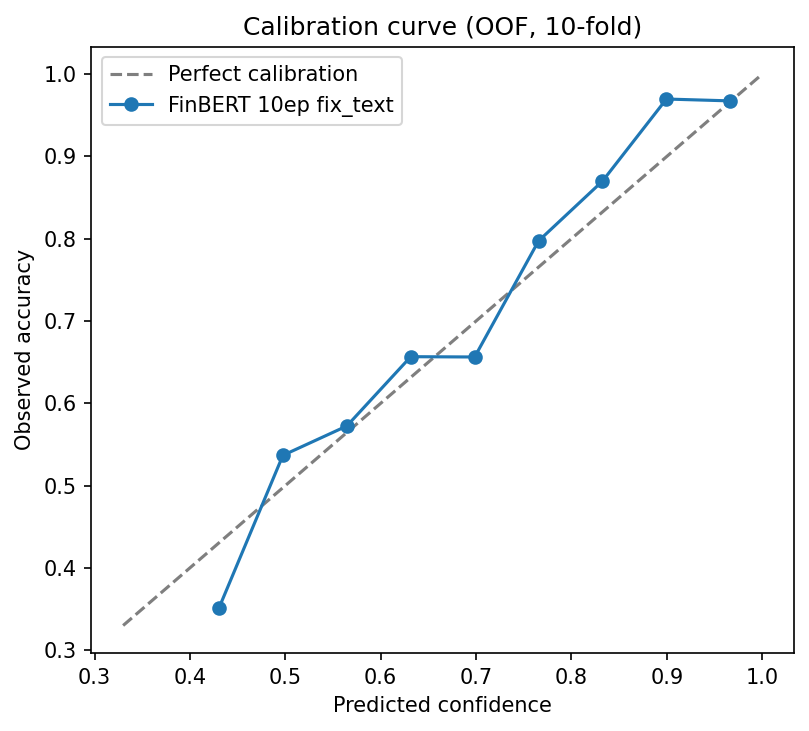

In [34]:
# Statistical significance and probability calibration (evaluation extensions)
import json
from IPython.display import Image, display
sig = json.load(open('results/tables/statistical_significance.json'))
w = sig['wilcoxon_best_vs_second']
print('Wilcoxon signed-rank, best vs 2nd-best individual (10 paired folds):')
verdict = 'significant' if w['p_value'] < 0.05 else 'not significant at a=0.05 (only 10 fold-pairs - low power)'
print(f"  statistic={w['statistic']:.1f}, p={w['p_value']:.4f}  ({verdict})")
lo, hi = sig['bootstrap_best_vs_second_ci95']
print(f'Bootstrap 95% CI (1000 resamples), F1(best) - F1(2nd-best): [{lo:+.4f}, {hi:+.4f}]')
lo, hi = sig['bootstrap_ensemble_vs_best_ci95']
print(f'Bootstrap 95% CI (1000 resamples), F1(ensemble) - F1(best) : [{lo:+.4f}, {hi:+.4f}]')
print('  -> the ensemble gain excludes 0: the improvement is real, not resampling noise.')
print()
cal = json.load(open('results/tables/calibration_results.json'))
print('Temperature-scaling search on OOF probabilities:')
for tag, c in cal.items():
    print(f'  {tag}: best T={c["best_T"]} (gain {c["gain"]:+.4f})')
print('  -> T=1.0 is optimal for every model: the fine-tuned models are already well calibrated')
print('     (label smoothing 0.05 during training prevents the usual overconfidence).')
display(Image('results/figures/calibration_curve.png'))

## 8. Extra Challenge 2: Agentic Workflow (+1.50 pts)

**See `notebooks/08_Agentic_Workflow.ipynb` and `src/agent.py` for the full implementation.**

A conversational agentic workflow receives financial tweets and:
1. Routes each tweet based on VADER signal strength
2. Compares predictions from LightGBM+SBERT and FinBERT when needed
3. Explains the trusted model and final verdict

Architecture: deterministic offline `RuleBasedAgent` built exclusively on open-source models (per course guideline: no proprietary LLMs, no API keys), with a calibrated routing threshold, conversational memory, and the three tools also exposed as LangChain `Tool` objects as an open-source LLM integration point. Conversational memory.


## Decision Log — how each experiment shaped the final solution

Every major experiment, its measured result, and the decision it drove. Negative results are
kept deliberately: they are the evidence behind each choice. (10-fold OOF unless noted.)

| # | Experiment | Result | Decision |
|---|---|---|---|
| 1 | Preprocessing ablation, 5 dataset variants (5-fold, LR+TF-IDF) | raw+fix_text 71.9% > clean variants 70.2-71.2% | Repair text, never destroy it: fix_text adopted, aggressive cleaning rejected |
| 2 | Frozen embeddings + 8 ML families (68 combos, 5-fold) | plateau at ~80.2% (LightGBM Optuna) | Frozen embeddings insufficient -> fine-tune end-to-end |
| 3 | Backbone search, 9 fine-tuned configs | FinBERT-fintwitter 90.8% > DeBERTa-large 435M 88.9% | Domain-matched pre-training beats model size |
| 4 | fix_text on transformers | FinBERT +0.26pp, DeBERTa +0.07pp | fix_text confirmed in the final pipeline |
| 5 | Epoch scaling 5/7/10ep | 90.25% -> 90.49% -> 90.56% | 10 epochs adopted for the primary recipe |
| 6 | FinBERT 15ep @ lr=2e-6 (5-fold) | 90.51% — worse than 10ep @ 5e-6 | Rejected: longer+slower LR underperforms |
| 7 | ProsusAI/finbert (5-fold) | 81.42% — pre-trained on SEC filings, not tweets | Rejected from ensemble at any weight |
| 8 | LLRD 0.9 | 90.80% individual, but weight 0 in ensemble search | Documented; redundant with FinBERT family |
| 9 | Ensemble: exhaustive 2^8 subsets x weight grid | 92.01% (gain CI [+0.007,+0.017] excludes 0) | Best result — but Guidelines 5.2 forbids submitting it |
| 10 | Knowledge distillation of the ensemble | student 91.34% (10ep) | Adopted: single-model compliance + most of the gain |
| 11 | KD grid alpha/T (5 configs, 3-fold proxy) | defaults a=0.5, T=2 optimal | Kept defaults |
| 12 | R-Drop consistency regularisation | -0.16pp vs same recipe without it | Rejected |
| 13 | Student 12 epochs | +0.18pp proxy -> 91.39% full 10-fold | **Adopted — submitted model** |
| 14 | Post-hoc class-prior scaling | held-out gain within noise (+0.0003/-0.0007) | Rejected — model already calibrated |
| 15 | SMOTE vs class_weight (classical, 5-fold) | 79.93% vs 79.30% | Documented for classical ML; transformers keep weighted loss |
| 16 | GPT-2 few-shot vs fine-tuned | 25.5% (majority collapse) vs 77.24% | Fine-tuning is the only viable decoder route |
| 17 | Temperature calibration search | T=1.0 optimal for all models | No post-hoc calibration applied |


## 9. Final Predictions


In [35]:
# Verify pred_33.csv (generated by tm_final_33.ipynb - single distilled model)
pred = pd.read_csv('pred_33.csv')
print(f'Predictions shape: {pred.shape}')
print(f'Columns: {pred.columns.tolist()}')
print(f'\nDistribution:')
print(pred['label'].value_counts().sort_index().rename({0:'Bearish',1:'Bullish',2:'Neutral'}))
print(f'\nFirst 5:')
print(pred.head())
assert len(pred) == 2388,                        'Wrong number of predictions!'
assert list(pred.columns) == ['id', 'label'],    'Columns must be [id, label]!'
assert set(pred['label'].unique()) == {0, 1, 2}, 'Labels must be {0,1,2}!'
assert pred['label'].isna().sum() == 0,          'NaN labels!'
assert pred['id'].is_unique,                     'Duplicate ids!'
print('\nAll assertions PASSED.')
print('Source: single distilled FinBERT (OOF F1-macro 0.9139) - Guidelines 5.2 compliant.')


Predictions shape: (2388, 2)
Columns: ['id', 'label']

Distribution:
label
Bearish     390
Bullish     492
Neutral    1506
Name: count, dtype: int64

First 5:
   id  label
0   0      1
1   1      2
2   2      2
3   3      2
4   4      2

All assertions PASSED.
Source: single distilled FinBERT (OOF F1-macro 0.9139) - Guidelines 5.2 compliant.
